In [38]:
pip install --force-reinstall ortools

  Using cached ortools-9.15.6755-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (3.3 kB)
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_vendor/resolvelib/resol

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__del__'
Traceback (most recent call last):
  File "_zmq.py", line 160, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


In [39]:
import pandas as pd
import numpy as np
df1 = pd.read_csv('sched.csv')
df2 = pd.read_csv('station_priorities.csv')
df3 = pd.read_csv('staff_limits.csv')
df = pd.merge(df1, df2, how='right')
df = pd.merge(df, df3, how='right')
freq = df['employee_id'].map(df['employee_id'].value_counts())

# Сортируем: сначала редкие (маленькая частота), потом частые (большая частота)
# Чтобы частые оказались внизу — sort_values(ascending=True)
df_sorted = df.iloc[freq.argsort(kind='stable')]
np.unique(df_sorted['employee_id'])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68])

In [40]:
req = pd.read_csv('reqlabor.csv')
req

,station_key,version,guests_count,reqlabor
0,BVR,будни/осн.,229,1
1,BVR,будни/осн.,375,2
2,BVR,будни/осн.,425,3
3,C,будни/осн.,36,1
4,C,будни/осн.,102,2
...,...,...,...,...
134,K,вых/утр.,312,11
135,K,вых/утр.,362,12
136,TS,вых/утр.,212,1
137,TS,вых/утр.,312,2


In [41]:
pd.read_csv('shifts.csv')

,shift_duration,shift_priority
0,3,2
1,4,3
2,5,4
3,6,4
4,7,1
5,8,1
6,9,1


На основе прогноза модельки составляем таблицу в которой по часам написано необходимое количество сотрудников на каждой станции

In [42]:
import pandas as pd

reqlabor = pd.read_csv('reqlabor.csv')
forecast = pd.read_excel('guests_forecast.xlsx')

forecast['sale_date'] = pd.to_datetime(forecast['sale_date'])
forecast['weekday'] = forecast['sale_date'].dt.dayofweek  # 0=пн, 6=вс

def get_version(weekday, hour):
    day_type = 'вых' if weekday >= 5 else 'будни'
    time_type = 'утр.' if hour < 10 else 'осн.'
    return f'{day_type}/{time_type}'

forecast['version'] = forecast.apply(
    lambda r: get_version(r['weekday'], r['sale_hour']), axis=1
)

def get_req(guests, version, station):
    rows = reqlabor[
        (reqlabor['version'] == version) &
        (reqlabor['station_key'] == station)
    ].sort_values('guests_count')

    # минимальный порог >= guests
    match = rows[rows['guests_count'] >= guests]
    if match.empty:
        return rows['reqlabor'].iloc[-1]  # максимум если превышаем все пороги
    return match.iloc[0]['reqlabor']

stations = ['BVR', 'C', 'FF', 'K', 'TS']

# Строим demand matrix: (date, hour, station) -> required_workers
demand = []
for _, row in forecast.iterrows():
    for station in stations:
        req = get_req(row['guests_count'], row['version'], station)
        demand.append({
            'ds': row['sale_date'].date(),
            'hour': row['sale_hour'],
            'station_key': station,
            'required': req
        })

demand_df = pd.DataFrame(demand)
demand_df

,ds,hour,station_key,required
0,2026-04-27,7,BVR,1
1,2026-04-27,7,C,2
2,2026-04-27,7,FF,1
3,2026-04-27,7,K,3
4,2026-04-27,7,TS,1
...,...,...,...,...
555,2026-05-03,22,BVR,1
556,2026-05-03,22,C,3
557,2026-05-03,22,FF,1
558,2026-05-03,22,K,4


In [43]:
demand_table = demand_df.pivot_table(
    index=['ds', 'hour'],
    columns='station_key',
    values='required',
    aggfunc='sum'
).reset_index()

# сортировка
demand_table = demand_table.sort_values(['ds', 'hour'])

demand_table

station_key,ds,hour,BVR,C,FF,K,TS
0,2026-04-27,7,1,2,1,3,1
1,2026-04-27,8,1,2,1,4,1
2,2026-04-27,9,1,2,1,5,1
3,2026-04-27,10,1,2,1,5,1
4,2026-04-27,11,1,2,1,5,1
...,...,...,...,...,...,...,...
107,2026-05-03,18,1,3,1,5,1
108,2026-05-03,19,1,3,1,5,1
109,2026-05-03,20,1,3,1,5,1
110,2026-05-03,21,1,3,1,4,1


график количества сотрудников 1

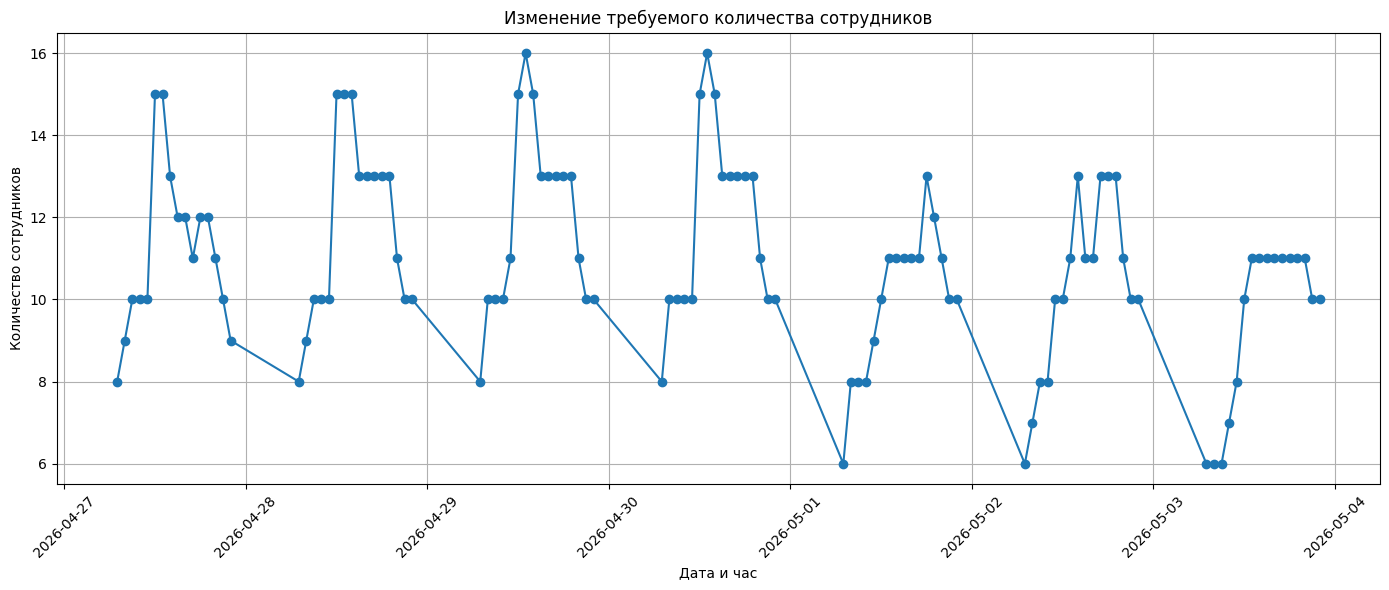

In [44]:
# @title
import pandas as pd
import matplotlib.pyplot as plt

# Общая потребность по всем станциям
total_staff = (
    demand_df.groupby(['ds', 'hour'])['required']
    .sum()
    .reset_index()
)

# Создаем datetime для красивого графика
total_staff['datetime'] = pd.to_datetime(
    total_staff['ds'].astype(str)
) + pd.to_timedelta(total_staff['hour'], unit='h')

# Сортировка
total_staff = total_staff.sort_values('datetime')

# График
plt.figure(figsize=(14, 6))

plt.plot(
    total_staff['datetime'],
    total_staff['required'],
    marker='o'
)

plt.xlabel('Дата и час')
plt.ylabel('Количество сотрудников')
plt.title('Изменение требуемого количества сотрудников')
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

график по станциям (график сотрудников 2)

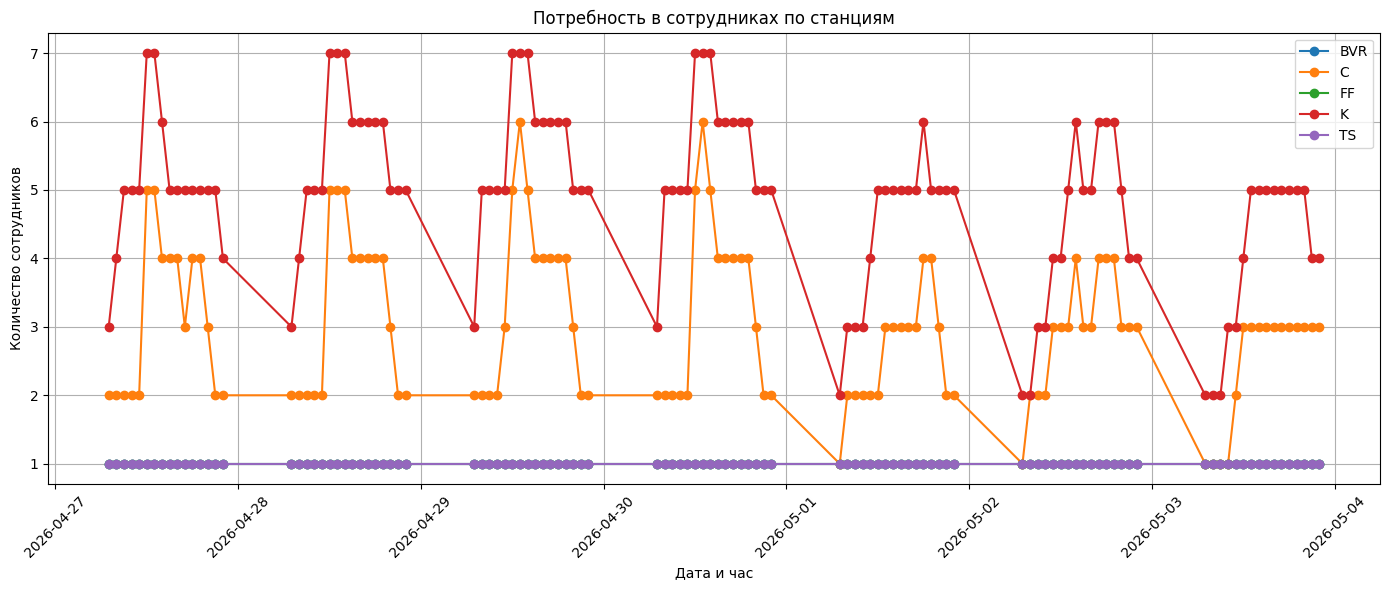

In [45]:
# @title
plt.figure(figsize=(14, 6))

for station in stations:
    station_data = demand_df[demand_df['station_key'] == station]

    station_grouped = (
        station_data.groupby(['ds', 'hour'])['required']
        .sum()
        .reset_index()
    )

    station_grouped['datetime'] = pd.to_datetime(
        station_grouped['ds'].astype(str)
    ) + pd.to_timedelta(station_grouped['hour'], unit='h')

    plt.plot(
        station_grouped['datetime'],
        station_grouped['required'],
        marker='o',
        label=station
    )

plt.xlabel('Дата и час')
plt.ylabel('Количество сотрудников')
plt.title('Потребность в сотрудниках по станциям')
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Неудачный алгоритм

In [46]:
import pandas as pd
from collections import defaultdict
from datetime import date, timedelta
import warnings
warnings.filterwarnings('ignore')

STATIONS        = ['BVR', 'C', 'FF', 'K', 'TS']
HOURS           = list(range(7, 23))
DAYS            = [date(2026, 4, 27) + timedelta(days=i) for i in range(7)]
MAX_OVERFLOW    = 2

reqlabor     = pd.read_csv('reqlabor.csv')
forecast     = pd.read_excel('guests_forecast.xlsx')
sched        = pd.read_csv('sched.csv')
shifts_df    = pd.read_csv('shifts.csv')
limits       = pd.read_csv('staff_limits.csv').set_index('employee_id')
station_prio = pd.read_csv('station_priorities.csv')

forecast['sale_date'] = pd.to_datetime(forecast['sale_date'])
forecast['weekday']   = forecast['sale_date'].dt.dayofweek

def get_version(wd, h):
    return f"{'вых' if wd >= 5 else 'будни'}/{'утр.' if h < 10 else 'осн.'}"

def get_req(guests, version, station):
    rows = reqlabor[
        (reqlabor['version'] == version) &
        (reqlabor['station_key'] == station)
    ].sort_values('guests_count')
    m = rows[rows['guests_count'] >= guests]
    return int(m.iloc[0]['reqlabor']) if not m.empty else int(rows.iloc[-1]['reqlabor'])

demand = {}
for _, row in forecast.iterrows():
    d = row['sale_date'].date()
    h = int(row['sale_hour'])
    if d not in DAYS or h not in HOURS:
        continue
    v = get_version(row['weekday'], h)
    for s in STATIONS:
        demand[(d, h, s)] = get_req(row['guests_count'], v, s)

total_demand      = sum(demand.values())
employees         = sorted(limits.index.unique())
station_prio_dict = station_prio.set_index(['employee_id', 'station_key'])['station_priority'].to_dict()
sched_dict        = {
    (int(r['employee_id']), int(r['day'])): (int(r['starttime']), int(r['finishtime']))
    for _, r in sched.iterrows()
}

def get_availability(emp, day_date):
    return sched_dict.get((emp, day_date.weekday() + 1))

shift_priority    = dict(zip(shifts_df['shift_duration'], shifts_df['shift_priority']))
allowed_durations = sorted(shift_priority.keys(), reverse=True)

# ─────────────────────────────────────────────────────────
cover        = defaultdict(int)
weekly_hours = defaultdict(int)
worked_days  = defaultdict(set)
schedule     = []

def assign_shift(emp, day, start, end, station):
    schedule.append({'ds': day, 'station_key': station,
                     'employee_id': emp, 'starttime': start, 'finishtime': end})
    for h in range(start, end):
        cover[(day, h, station)] += 1
    weekly_hours[emp] += (end - start)
    worked_days[emp].add(day)

def remove_shift(shift):
    schedule.remove(shift)
    d, s = shift['ds'], shift['station_key']
    for h in range(shift['starttime'], shift['finishtime']):
        cover[(d, h, s)] -= 1
    weekly_hours[shift['employee_id']] -= (shift['finishtime'] - shift['starttime'])
    worked_days[shift['employee_id']].discard(shift['ds'])
    # БАГ 1: discard убирает день не проверив, есть ли у сотрудника
    # другие смены в тот же день. worked_days может стать некорректным.
    for s2 in schedule:
        if s2['employee_id'] == shift['employee_id'] and s2['ds'] == shift['ds']:
            worked_days[shift['employee_id']].add(shift['ds'])
            break

def calculate_deficit(d, h, s):
    return max(0, demand.get((d, h, s), 0) - cover[(d, h, s)])

def total_deficit():
    return sum(calculate_deficit(d, h, s) for d in DAYS for h in HOURS for s in STATIONS)

def can_assign(emp, day, start, end, station):
    dur = end - start
    if dur > int(limits.loc[emp, 'shift_limit']):         return False
    if weekly_hours[emp] + dur > int(limits.loc[emp, 'worktime_limit']): return False
    if day in worked_days[emp]:                            return False
    if len(worked_days[emp]) >= 5:                         return False
    avail = get_availability(emp, day)
    if not avail:                                          return False
    av_start = max(avail[0], 7)
    av_end   = min(avail[1], 23)
    if start < av_start or end > av_end:                  return False
    return True

def shift_score(emp, day, start, end, station):
    # БАГ 2: скор считается только по текущему моменту.
    # Алгоритм не знает, что поставив сотрудника сюда,
    # он заблокирует более выгодное назначение в другой день.
    dur      = end - start
    sp       = station_prio_dict.get((emp, station), 4)
    shp      = shift_priority.get(dur, 4)
    coverage = sum(min(calculate_deficit(day, h, station), 1) for h in range(start, end))
    return coverage * 100 - sp * 10 - shp * 3

# ── ФАЗА 1 ───────────────────────────────────────────────
print("Фаза 1: начальное назначение")
for emp in sorted(employees):
    if worked_days[emp]:
        continue
    best, best_score = None, -999
    for day in DAYS:
        avail = get_availability(emp, day)
        if not avail:
            continue
        av_start = max(avail[0], 7)
        av_end   = min(avail[1], 23)
        for station in sorted(STATIONS, key=lambda s: station_prio_dict.get((emp, s), 4)):
            for dur in allowed_durations:
                if not can_assign(emp, day, av_start, av_start + dur, station):
                    continue
                for start in range(av_start, av_end - dur + 1):
                    end = start + dur
                    sc  = shift_score(emp, day, start, end, station)
                    if sc > best_score:
                        best_score = sc
                        best       = (day, start, end, station)
    if best:
        assign_shift(emp, best[0], best[1], best[2], best[3])

print(f"  После фазы 1: {len(schedule)} смен, дефицит={total_deficit()}")

# ── ФАЗА 2 ───────────────────────────────────────────────
print("\nФаза 2: закрытие дефицита")

# БАГ 3: жёсткий лимит 500 итераций — если не хватило, останавливается
# с остаточным дефицитом. MILP либо находит оптимум, либо доказывает невозможность.
for iteration in range(500):
    if total_deficit() == 0:
        break
    if iteration % 50 == 0:
        print(f"  Итер {iteration}: дефицит={total_deficit()}, смен={len(schedule)}")

    deficit_slots = sorted(
        [(calculate_deficit(d, h, s), d, h, s)
         for d in DAYS for h in HOURS for s in STATIONS
         if calculate_deficit(d, h, s) > 0],
        reverse=True
    )
    if not deficit_slots:
        break

    improved = False

    # БАГ 4: обрабатываем только топ-10 слотов за итерацию.
    # Остальные дефицитные слоты откладываются и могут не закрыться никогда.
    for dv, d, h, s in deficit_slots[:10]:
        best_emp, best_config, best_score = None, None, -1
        sorted_emps = sorted(employees,
                             key=lambda e: (station_prio_dict.get((e, s), 4), weekly_hours[e]))
        for emp in sorted_emps:
            avail = get_availability(emp, d)
            if not avail:
                continue
            av_start  = max(avail[0], 7)
            av_end    = min(avail[1], 23)
            if not (av_start <= h < av_end):
                continue
            wl        = int(limits.loc[emp, 'worktime_limit'])
            sl        = int(limits.loc[emp, 'shift_limit'])
            remaining = wl - weekly_hours[emp]

            if d not in worked_days[emp] and len(worked_days[emp]) < 5 and remaining >= 4:
                for dur in allowed_durations:
                    if dur > sl or dur > remaining:
                        continue
                    for start in range(max(av_start, h - dur + 1), min(h + 1, av_end - dur + 1)):
                        end = start + dur
                        if not (start <= h < end):
                            continue
                        if not all(cover[(d, hh, s)] + 1 <= demand.get((d, hh, s), 0) + MAX_OVERFLOW
                                   for hh in range(start, end)):
                            continue
                        cov = sum(1 for hh in range(start, end) if calculate_deficit(d, hh, s) > 0)
                        sc  = cov * 100 - station_prio_dict.get((emp, s), 4) * 10 - shift_priority.get(dur, 4) * 3
                        if sc > best_score:
                            best_score, best_emp, best_config = sc, emp, ('new', start, end)

            existing = [a for a in schedule
                        if a['employee_id'] == emp and a['ds'] == d and a['station_key'] == s]
            if existing and remaining > 0:
                shift     = existing[0]
                cur_start = shift['starttime']
                cur_end   = shift['finishtime']
                if h < cur_start and cur_start > av_start:
                    new_start = max(av_start, h)
                    added     = cur_start - new_start
                    if cur_end - new_start <= sl and weekly_hours[emp] + added <= wl:
                        if all(cover[(d, hh, s)] + 1 <= demand.get((d, hh, s), 0) + MAX_OVERFLOW
                               for hh in range(new_start, cur_start)):
                            cov = sum(1 for hh in range(new_start, cur_start) if calculate_deficit(d, hh, s) > 0)
                            if cov * 100 > best_score:
                                best_score, best_emp, best_config = cov * 100, emp, ('extend', new_start, cur_end, shift)
                if h >= cur_end and cur_end < av_end:
                    new_end = min(av_end, h + 1)
                    added   = new_end - cur_end
                    if new_end - cur_start <= sl and weekly_hours[emp] + added <= wl:
                        if all(cover[(d, hh, s)] + 1 <= demand.get((d, hh, s), 0) + MAX_OVERFLOW
                               for hh in range(cur_end, new_end)):
                            cov = sum(1 for hh in range(cur_end, new_end) if calculate_deficit(d, hh, s) > 0)
                            if cov * 100 > best_score:
                                best_score, best_emp, best_config = cov * 100, emp, ('extend', cur_start, new_end, shift)

        if best_emp and best_config:
            if best_config[0] == 'new':
                assign_shift(best_emp, d, best_config[1], best_config[2], s)
            else:
                emp = best_config[3]['employee_id']
                remove_shift(best_config[3])
                assign_shift(emp, d, best_config[1], best_config[2], s)
            improved = True

    # БАГ 5: застрял в локальном минимуме — выходим без результата.
    # Настоящего backtracking нет вообще, несмотря на название в оригинале.
    if not improved:
        print(f"  Застрял на итерации {iteration}, дефицит={total_deficit()}")
        break

print(f"Фаза 2 завершена: {len(schedule)} смен, дефицит={total_deficit()}")

# ── ФАЗА 3 ───────────────────────────────────────────────
print("\nФаза 3: финальная зачистка")

# БАГ 6: рассматриваются только сотрудники БЕЗ смены в этот день.
# Перераспределение уже назначенных смен не рассматривается —
# даже если это дало бы лучший глобальный результат.
for _ in range(100):
    if total_deficit() == 0:
        break
    deficit_slots = sorted(
        [(calculate_deficit(d, h, s), d, h, s)
         for d in DAYS for h in HOURS for s in STATIONS
         if calculate_deficit(d, h, s) > 0],
        reverse=True
    )
    improved = False
    for dv, d, h, s in deficit_slots[:5]:
        for emp in sorted(employees, key=lambda e: station_prio_dict.get((e, s), 4)):
            if d in worked_days[emp] or len(worked_days[emp]) >= 5:
                continue
            avail = get_availability(emp, d)
            if not avail or not (max(avail[0], 7) <= h < min(avail[1], 23)):
                continue
            wl, sl    = int(limits.loc[emp, 'worktime_limit']), int(limits.loc[emp, 'shift_limit'])
            remaining = wl - weekly_hours[emp]
            if remaining < 4:
                continue
            av_start, av_end = max(avail[0], 7), min(avail[1], 23)
            for dur in sorted(allowed_durations):
                if dur > sl or dur > remaining:
                    continue
                for start in range(max(av_start, h - dur + 1), min(h + 1, av_end - dur + 1)):
                    end = start + dur
                    if not (start <= h < end):
                        continue
                    if all(cover[(d, hh, s)] + 1 <= demand.get((d, hh, s), 0) + MAX_OVERFLOW
                           for hh in range(start, end)):
                        assign_shift(emp, d, start, end, s)
                        improved = True
                        break
                if improved:
                    break
            if improved:
                break
    if not improved:
        break

print(f"Фаза 3 завершена: {len(schedule)} смен, дефицит={total_deficit()}")

# ── ИТОГ ─────────────────────────────────────────────────
total_covered = sum(
    min(cover[(d, h, s)], demand.get((d, h, s), 0))
    for d in DAYS for h in HOURS for s in STATIONS
)
coverage_pct = 100 * total_covered / total_demand if total_demand > 0 else 0
print("Итог")
print(f"Смен:      {len(schedule)}")
print(f"Покрытие:  {total_covered}/{total_demand} ({coverage_pct:.2f}%)")
print(f"Дефицит:   {total_deficit()} чел.-часов")
print()
print("Итог по багам:")
print("  БАГ 1 — remove_shift ломает worked_days")
print("  БАГ 2 — локальный скор без взгляда вперёд")
print("  БАГ 3 — лимит 500 итераций, нет гарантии завершения")
print("  БАГ 4 — только топ-10 слотов за итерацию")
print("  БАГ 5 — нет настоящего backtracking, застревает")
print("  БАГ 6 — фаза 3 не переназначает уже занятых сотрудников")


Фаза 1: начальное назначение
  После фазы 1: 69 смен, дефицит=780

Фаза 2: закрытие дефицита
  Итер 0: дефицит=780, смен=69
  Застрял на итерации 16, дефицит=164
Фаза 2 завершена: 176 смен, дефицит=164

Фаза 3: финальная зачистка
Фаза 3 завершена: 176 смен, дефицит=164
Итог
Смен:      176
Покрытие:  1060/1224 (86.60%)
Дефицит:   164 чел.-часов

Итог по багам:
  БАГ 1 — remove_shift ломает worked_days
  БАГ 2 — локальный скор без взгляда вперёд
  БАГ 3 — лимит 500 итераций, нет гарантии завершения
  БАГ 4 — только топ-10 слотов за итерацию
  БАГ 5 — нет настоящего backtracking, застревает
  БАГ 6 — фаза 3 не переназначает уже занятых сотрудников


# Форматирование прогноза для Kaggle

In [47]:
import pandas as pd

# Загрузка данных из Excel
df = pd.read_excel('guests_forecast.xlsx')

# Формирование колонки ID: год-месяц-день-час
df['ID'] = df['sale_date'].astype(str) + '-' + df['sale_hour'].astype(str).str.zfill(2)

# Выбор нужных колонок
result = df[['ID', 'guests_count']]

# Сохранение в CSV (пример)
result.to_csv('guests_forecast_result.csv', index=False)

# Показать первые строки результата
print(result.head(10))

              ID  guests_count
0  2026-04-27-07            44
1  2026-04-27-08            80
2  2026-04-27-09            85
3  2026-04-27-10            74
4  2026-04-27-11            94
5  2026-04-27-12           161
6  2026-04-27-13           175
7  2026-04-27-14           146
8  2026-04-27-15           128
9  2026-04-27-16           127


# MILP Планировщик смен
Оптимальное расписание на основе Integer Linear Programming (PuLP + CBC)

## 1. Импорты и конфигурация

In [48]:
import pandas as pd
import numpy as np
import pulp
from collections import defaultdict
from datetime import date, timedelta
import warnings
warnings.filterwarnings('ignore')

print(f'PuLP version: {pulp.__version__}')

# Станции, часы работы, плановая неделя
STATIONS     = ['BVR', 'C', 'FF', 'K', 'TS']
HOURS        = list(range(7, 23))          # 7:00 – 22:00
DAYS         = [date(2026, 4, 27) + timedelta(days=i) for i in range(7)]
MAX_OVERFLOW = 2   # макс. допустимое превышение спроса на слот

print('Станции:', STATIONS)
print('Дни:', [d.strftime('%a %m/%d') for d in DAYS])

PuLP version: 3.3.0
Станции: ['BVR', 'C', 'FF', 'K', 'TS']
Дни: ['Mon 04/27', 'Tue 04/28', 'Wed 04/29', 'Thu 04/30', 'Fri 05/01', 'Sat 05/02', 'Sun 05/03']


## 2. Загрузка данных

In [49]:
reqlabor     = pd.read_csv('reqlabor.csv')
forecast     = pd.read_excel('guests_forecast.xlsx')
sched        = pd.read_csv('sched.csv')
shifts_df    = pd.read_csv('shifts.csv')
limits       = pd.read_csv('staff_limits.csv').set_index('employee_id')
station_prio = pd.read_csv('station_priorities.csv')

print('reqlabor:    ', reqlabor.shape)
print('forecast:    ', forecast.shape)
print('sched:       ', sched.shape)
print('shifts_df:   ', shifts_df.shape)
print('limits:      ', limits.shape)
print('station_prio:', station_prio.shape)

reqlabor:     (139, 4)
forecast:     (112, 3)
sched:        (313, 4)
shifts_df:    (7, 2)
limits:       (69, 2)
station_prio: (345, 3)


## 3. Построение demand_dictionary
Ступенчатая интерполяция вверх: прогноз гостей - потребность в персонале по каждой станции и каждому часу.

In [50]:
forecast['sale_date'] = pd.to_datetime(forecast['sale_date'])
forecast['weekday']   = forecast['sale_date'].dt.dayofweek


def get_version(weekday: int, hour: int) -> str:
    """Определяет версию нормативов: будни/выходные × утро/основное."""
    day_type  = 'вых'   if weekday >= 5 else 'будни'
    time_type = 'утр.'  if hour < 10    else 'осн.'
    return f'{day_type}/{time_type}'


def get_req(guests: int, version: str, station: str) -> int:
    """Ступенчатая интерполяция вверх по таблице нормативов."""
    rows = reqlabor[
        (reqlabor['version']     == version) &
        (reqlabor['station_key'] == station)
    ].sort_values('guests_count')

    above = rows[rows['guests_count'] >= guests]
    if not above.empty:
        return int(above.iloc[0]['reqlabor'])
    return int(rows.iloc[-1]['reqlabor'])   # выше максимума таблицы


# Заполняем словарь спроса
demand: dict = {}

for _, row in forecast.iterrows():
    d = row['sale_date'].date()
    h = int(row['sale_hour'])
    if d not in DAYS or h not in HOURS:
        continue
    v = get_version(row['weekday'], h)
    for s in STATIONS:
        demand[(d, h, s)] = get_req(row['guests_count'], v, s)

total_demand = sum(demand.values())
print(f'Слотов в demand: {len(demand)}')
print(f'Суммарный спрос: {total_demand} чел.-часов')

Слотов в demand: 560
Суммарный спрос: 1224 чел.-часов


## 4. Модель сотрудников
Доступность по дням, лимиты часов, приоритеты станций.

In [51]:
employees = sorted(limits.index.unique())
print(f'Сотрудников: {len(employees)}')

# Приоритеты станций: (emp, station) → приоритет (меньше = лучше)
station_prio_dict: dict = (
    station_prio
    .set_index(['employee_id', 'station_key'])['station_priority']
    .to_dict()
)

# Окна доступности: (emp, день_недели_1..7) - (start, end)
sched_dict: dict = {
    (int(r['employee_id']), int(r['day'])): (int(r['starttime']), int(r['finishtime']))
    for _, r in sched.iterrows()
}


def get_availability(emp: int, day_date: date):
    """Возвращает (start, end) доступности или None."""
    return sched_dict.get((emp, day_date.weekday() + 1))


# Допустимые длины смен (по убыванию) и их приоритеты
shift_priority   = dict(zip(shifts_df['shift_duration'], shifts_df['shift_priority']))
allowed_durations = sorted(shift_priority.keys(), reverse=True)
print('Допустимые длины смен:', allowed_durations)

Сотрудников: 69
Допустимые длины смен: [9, 8, 7, 6, 5, 4, 3]


## 5. Генерация полного пространства решений (shift_options)
Все допустимые комбинации (сотрудник, день, начало, конец, станция).

In [52]:
shift_options = []   # (emp, day, start, end, station)

for emp in employees:
    sl = int(limits.loc[emp, 'shift_limit'])

    for day in DAYS:
        avail = get_availability(emp, day)
        if not avail:
            continue

        av_start = max(avail[0], 7)
        av_end   = min(avail[1], 23)

        for dur in allowed_durations:
            if dur > sl:
                continue
            for start in range(av_start, av_end - dur + 1):
                end = start + dur
                for station in STATIONS:
                    shift_options.append((emp, day, start, end, station))

print(f'Вариантов смен в пространстве решений: {len(shift_options):,}')

Вариантов смен в пространстве решений: 57,410


## 6. Проверка реализуемости (до запуска солвера)

In [53]:
print('Проверка доступных человеко-часов по дням:\n')

for day in DAYS:
    avail_hours = 0
    for emp in employees:
        avail = get_availability(emp, day)
        if avail:
            sl  = int(limits.loc[emp, 'shift_limit'])
            wl  = int(limits.loc[emp, 'worktime_limit'])
            av_start = max(avail[0], 7)
            av_end   = min(avail[1], 23)
            avail_hours += max(0, min(sl, av_end - av_start, wl))

    day_demand = sum(demand.get((day, h, s), 0) for h in HOURS for s in STATIONS)
    status = '✓' if avail_hours >= day_demand else '⚠ TIGHT'
    print(f'  {day.strftime("%a %m/%d")}: спрос={day_demand}, макс_доступно={avail_hours}  {status}')

Проверка доступных человеко-часов по дням:

  Mon 04/27: спрос=179, макс_доступно=283  ✓
  Tue 04/28: спрос=188, макс_доступно=303  ✓
  Wed 04/29: спрос=191, макс_доступно=295  ✓
  Thu 04/30: спрос=190, макс_доступно=314  ✓
  Fri 05/01: спрос=160, макс_доступно=306  ✓
  Sat 05/02: спрос=165, макс_доступно=289  ✓
  Sun 05/03: спрос=151, макс_доступно=316  ✓


## 7. Построение ILP-модели (PuLP)

In [54]:
prob = pulp.LpProblem('ShiftScheduler', pulp.LpMinimize)

# Переменные решения: x[i] = 1 если смена i включена в расписание
x = [pulp.LpVariable(f'x_{i}', cat='Binary') for i in range(len(shift_options))]

# Индекс: (день, час, станция) → список индексов смен, покрывающих слот
coverage_index: dict = defaultdict(list)
for i, (emp, day, start, end, station) in enumerate(shift_options):
    for h in range(start, end):
        if h in HOURS:
            coverage_index[(day, h, station)].append(i)

# Индекс: emp → day → список (i, start, end)
emp_day_index: dict = defaultdict(lambda: defaultdict(list))
for i, (emp, day, start, end, station) in enumerate(shift_options):
    emp_day_index[emp][day].append((i, start, end))

# Индекс: emp → список (i, day, duration)
emp_options: dict = defaultdict(list)
for i, (emp, day, start, end, station) in enumerate(shift_options):
    emp_options[emp].append((i, day, end - start))

# Переменные дефицита: δ ≥ 0 (нехватка людей на слот)
deficit_vars: dict = {
    (d, h, s): pulp.LpVariable(f'def_{d}_{h}_{s}', lowBound=0, cat='Integer')
    for d in DAYS for h in HOURS for s in STATIONS
    if (d, h, s) in demand
}

print(f'Переменных x:       {len(x):,}')
print(f'Переменных дефицита: {len(deficit_vars):,}')

Переменных x:       57,410
Переменных дефицита: 560


## 8. Целевая функция и ограничения


In [55]:
# Цель: минимизировать суммарный дефицит
prob += pulp.lpSum(deficit_vars.values())

# Ограничения покрытия
for d in DAYS:
    for h in HOURS:
        for s in STATIONS:
            cov = pulp.lpSum(x[i] for i in coverage_index.get((d, h, s), []))

            # Жёсткое: минимум 1 человек на станции в каждый час
            prob += cov >= 1, f'min1_{d}_{h}_{s}'

            req = demand.get((d, h, s), 0)
            if req > 0:
                # Мягкое: покрытие + дефицит >= спрос
                prob += cov + deficit_vars[(d, h, s)] >= req, f'cov_{d}_{h}_{s}'
                # Ограничение переполнения: не более спрос + MAX_OVERFLOW
                prob += cov <= req + MAX_OVERFLOW, f'ovf_{d}_{h}_{s}'

# Ограничения на сотрудников
for emp in employees:
    wl = int(limits.loc[emp, 'worktime_limit'])

    # Один выход в день
    for day in DAYS:
        opts = emp_day_index[emp][day]
        if opts:
            prob += pulp.lpSum(x[i] for i, _, _ in opts) <= 1, f'oneday_{emp}_{day}'

    # Недельный лимит часов
    opts = emp_options[emp]
    if opts:
        prob += pulp.lpSum(dur * x[i] for i, _, dur in opts) <= wl, f'weekly_{emp}'

    # Минимум 1 рабочий день
    if opts:
        prob += pulp.lpSum(x[i] for i, _, _ in opts) >= 1, f'minwork_{emp}'

    # Максимум 5 рабочих дней (вспомогательные бинарные переменные w)
    day_vars = []
    for day in DAYS:
        day_opts = emp_day_index[emp][day]
        if day_opts:
            w = pulp.LpVariable(f'worked_{emp}_{day}', cat='Binary')
            prob += w == pulp.lpSum(x[i] for i, _, _ in day_opts)
            day_vars.append(w)
    if day_vars:
        prob += pulp.lpSum(day_vars) <= 5, f'maxdays_{emp}'

print(f'Ограничений добавлено: {len(prob.constraints):,}')

Ограничений добавлено: 2,509


## 9. Запуск CBC-солвера

In [56]:
solver = pulp.PULP_CBC_CMD(msg=1, timeLimit=300, gapRel=0.01)
prob.solve(solver)

print(f'\nСтатус:    {pulp.LpStatus[prob.status]}')
print(f'Дефицит:   {int(pulp.value(prob.objective))} чел.-часов')


Статус:    Optimal
Дефицит:   0 чел.-часов


## 10. Извлечение расписания из решения

In [57]:
schedule     = []
cover        = defaultdict(int)
weekly_hours = defaultdict(int)
worked_days  = defaultdict(set)

for i, (emp, day, start, end, station) in enumerate(shift_options):
    if pulp.value(x[i]) and pulp.value(x[i]) > 0.5:
        schedule.append({
            'ds': day, 'station_key': station,
            'employee_id': emp, 'starttime': start, 'finishtime': end
        })
        for h in range(start, end):
            cover[(day, h, station)] += 1
        weekly_hours[emp]  += (end - start)
        worked_days[emp].add(day)

print(f'Назначено смен: {len(schedule)}')

Назначено смен: 218


## 11. Финальный отчёт

In [58]:
final_deficit = sum(
    max(0, demand.get((d, h, s), 0) - cover[(d, h, s)])
    for d in DAYS for h in HOURS for s in STATIONS
)
total_covered = sum(
    min(cover[(d, h, s)], demand.get((d, h, s), 0))
    for d in DAYS for h in HOURS for s in STATIONS
)
overflow_slots = sum(
    1 for d in DAYS for h in HOURS for s in STATIONS
    if cover[(d, h, s)] > demand.get((d, h, s), 0) + MAX_OVERFLOW
)
empty_slots = [
    (d, h, s) for d in DAYS for h in HOURS for s in STATIONS
    if cover[(d, h, s)] == 0
]

coverage_pct = 100 * total_covered / total_demand if total_demand > 0 else 100

print('ИТОГИ')
print(f'Смен назначено:       {len(schedule)}')
print(f'Покрытие:             {total_covered}/{total_demand}  ({coverage_pct:.2f}%)')
print(f'Дефицит:              {final_deficit} чел.-часов')
print(f'Переполнений (>{MAX_OVERFLOW}):    {overflow_slots}')

hours_viol = sum(1 for e in employees if weekly_hours[e] > int(limits.loc[e, 'worktime_limit']))
shift_viol = sum(
    1 for s in schedule
    if (s['finishtime'] - s['starttime']) > int(limits.loc[s['employee_id'], 'shift_limit'])
)
days_viol    = sum(1 for e in employees if len(worked_days[e]) > 5)
no_work_viol = sum(1 for e in employees if len(worked_days[e]) == 0)

print()
print('Проверка ограничений:')
print(f'Нарушений недельных часов:   {hours_viol}')
print(f'Нарушений длины смены:       {shift_viol}')
print(f'Нарушений макс. дней (>5):   {days_viol}')
print(f'Сотрудников без смен:        {no_work_viol}')
print(f'Пустых слотов станций:       {len(empty_slots)}')

print()
print('Покрытие по дням:')
for d in DAYS:
    day_dem = sum(demand.get((d, h, s), 0) for h in HOURS for s in STATIONS)
    day_cov = sum(min(cover[(d, h, s)], demand.get((d, h, s), 0)) for h in HOURS for s in STATIONS)
    pct     = 100 * day_cov / day_dem if day_dem > 0 else 100
    status  = '✓' if day_cov == day_dem else f'⚠ {pct:.1f}%'
    print(f'  {d.strftime("%a %m/%d")}: {day_cov}/{day_dem}  {status}')

ИТОГИ
Смен назначено:       218
Покрытие:             1224/1224  (100.00%)
Дефицит:              0 чел.-часов
Переполнений (>2):    0

Проверка ограничений:
Нарушений недельных часов:   0
Нарушений длины смены:       0
Нарушений макс. дней (>5):   0
Сотрудников без смен:        0
Пустых слотов станций:       0

Покрытие по дням:
  Mon 04/27: 179/179  ✓
  Tue 04/28: 188/188  ✓
  Wed 04/29: 191/191  ✓
  Thu 04/30: 190/190  ✓
  Fri 05/01: 160/160  ✓
  Sat 05/02: 165/165  ✓
  Sun 05/03: 151/151  ✓


# Аналитика

In [59]:
"""
Export schedule_result.csv → schedule_result.xlsx
Sheets: Расписание, Покрытие, Gantt (per day), Сотрудники
"""

import pandas as pd
from collections import defaultdict
from datetime import date, timedelta
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ── CONFIG ────────────────────────────────────────────────
STATIONS = ['BVR', 'C', 'FF', 'K', 'TS']
STATION_NAMES = {'BVR': 'Напитки', 'C': 'Прилавок', 'FF': 'Картофель', 'K': 'Кухня', 'TS': 'Зал'}
HOURS = list(range(7, 23))
DAYS = [date(2026, 4, 27) + timedelta(days=i) for i in range(7)]
DAY_RU = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
OUTPUT = 'schedule_result.xlsx'

STATION_COLORS = {
    'BVR': 'D6E4F7',
    'C':   'FCE4D6',
    'FF':  'E2EFDA',
    'K':   'FFF2CC',
    'TS':  'EAD1DC',
}

# ── LOAD DATA ─────────────────────────────────────────────
sched_df = pd.read_csv('schedule_result.csv')
sched_df['ds'] = pd.to_datetime(sched_df['ds']).dt.date
sched_df = sched_df.sort_values(['ds', 'station_key', 'starttime'])

reqlabor = pd.read_csv('reqlabor.csv')
forecast = pd.read_excel('guests_forecast.xlsx')
forecast['sale_date'] = pd.to_datetime(forecast['sale_date'])
forecast['weekday'] = forecast['sale_date'].dt.dayofweek

limits_df = pd.read_csv('staff_limits.csv').set_index('employee_id')
employees = sorted(limits_df.index.unique())

def get_version(wd, h):
    return f"{'вых' if wd >= 5 else 'будни'}/{'утр.' if h < 10 else 'осн.'}"

def get_req(guests, version, station):
    rows = reqlabor[(reqlabor['version'] == version) & (reqlabor['station_key'] == station)].sort_values('guests_count')
    m = rows[rows['guests_count'] >= guests]
    return int(m.iloc[0]['reqlabor']) if not m.empty else int(rows.iloc[-1]['reqlabor'])

demand = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
for _, row in forecast.iterrows():
    d = row['sale_date'].date()
    h = int(row['sale_hour'])
    if d not in DAYS or h not in HOURS:
        continue
    v = get_version(row['weekday'], h)
    for s in STATIONS:
        demand[d][h][s] = get_req(row['guests_count'], v, s)

# Build cover map
cover = defaultdict(int)
weekly_hours = defaultdict(int)
worked_days = defaultdict(set)
for _, row in sched_df.iterrows():
    emp, d = int(row['employee_id']), row['ds']
    s = row['station_key']
    for h in range(int(row['starttime']), int(row['finishtime'])):
        cover[(d, h, s)] += 1
    weekly_hours[emp] += int(row['finishtime']) - int(row['starttime'])
    worked_days[emp].add(d)

# STYLE HELPERS
DARK_BLUE  = '1F4E79'
MID_BLUE   = '2E75B6'
LIGHT_GREY = 'F2F2F2'
GREEN_OK   = 'C6EFCE'
RED_ERR    = 'FFC7CE'
YELLOW_WRN = 'FFEB9C'
WHITE      = 'FFFFFF'

hfill = PatternFill('solid', fgColor=DARK_BLUE)
hfont = Font(bold=True, color=WHITE, name='Arial', size=10)
cfont = Font(name='Arial', size=10)
bfont = Font(bold=True, name='Arial', size=10)
ctr   = Alignment(horizontal='center', vertical='center', wrap_text=False)
ctr_w = Alignment(horizontal='center', vertical='center', wrap_text=True)
thin  = Side(style='thin', color='CCCCCC')
bdr   = Border(left=thin, right=thin, top=thin, bottom=thin)

def hdr(ws, r, c, v, width=None):
    cell = ws.cell(r, c, v)
    cell.fill = hfill
    cell.font = hfont
    cell.alignment = ctr
    cell.border = bdr
    return cell

def cell(ws, r, c, v, fill=None, font=None, align=None, bold=False):
    cl = ws.cell(r, c, v)
    cl.font = bfont if bold else (font or cfont)
    cl.alignment = align or ctr
    cl.border = bdr
    if fill:
        cl.fill = PatternFill('solid', fgColor=fill)
    return cl

def freeze(ws, row, col):
    ws.freeze_panes = ws.cell(row, col)

# SHEET 1: РАСПИСАНИЕ
wb = Workbook()
ws1 = wb.active
ws1.title = 'Расписание'

headers = ['Дата', 'День', 'Станция', 'Название станции', 'ID сотрудника', 'Начало', 'Конец', 'Длина (ч)']
for ci, h in enumerate(headers, 1):
    hdr(ws1, 1, ci, h)

for ri, row in enumerate(sched_df.itertuples(), 2):
    d = row.ds
    sc = STATION_COLORS.get(row.station_key, 'FFFFFF')
    dur = int(row.finishtime) - int(row.starttime)
    vals = [str(d), DAY_RU[d.weekday()], row.station_key,
            STATION_NAMES.get(row.station_key, ''), int(row.employee_id),
            int(row.starttime), int(row.finishtime), dur]
    for ci, v in enumerate(vals, 1):
        c = ws1.cell(ri, ci, v)
        c.font = cfont
        c.alignment = ctr
        c.border = bdr
        c.fill = PatternFill('solid', fgColor=sc)

ws1.column_dimensions['A'].width = 13
ws1.column_dimensions['B'].width = 7
ws1.column_dimensions['C'].width = 9
ws1.column_dimensions['D'].width = 14
ws1.column_dimensions['E'].width = 14
ws1.column_dimensions['F'].width = 9
ws1.column_dimensions['G'].width = 9
ws1.column_dimensions['H'].width = 11
ws1.row_dimensions[1].height = 30
ws1.auto_filter.ref = f'A1:H{len(sched_df)+1}'
freeze(ws1, 2, 1)

# ── SHEET 2: ПОКРЫТИЕ ─────────────────────────────────────
ws2 = wb.create_sheet('Покрытие')
h2 = ['Дата', 'День', 'Час', 'Станция', 'Название', 'Требуется', 'Назначено', 'Дельта', 'Статус']
for ci, h in enumerate(h2, 1):
    hdr(ws2, 1, ci, h)

ri = 2
for d in DAYS:
    for h in HOURS:
        for s in STATIONS:
            req = demand[d][h][s]
            act = cover[(d, h, s)]
            delta = act - req
            if act < req:
                status, fc = f'−{req-act}', RED_ERR
            elif act > req + 2:
                status, fc = f'+{act-req} ⚠', YELLOW_WRN
            else:
                status, fc = '✓ OK', GREEN_OK

            vals = [str(d), DAY_RU[d.weekday()], h, s,
                    STATION_NAMES.get(s,''), req, act, delta, status]
            for ci, v in enumerate(vals, 1):
                c = ws2.cell(ri, ci, v)
                c.font = cfont
                c.alignment = ctr
                c.border = bdr
                c.fill = PatternFill('solid', fgColor=fc)
            ri += 1

for ci, w in enumerate([13, 7, 7, 9, 14, 12, 12, 10, 11], 1):
    ws2.column_dimensions[get_column_letter(ci)].width = w
ws2.row_dimensions[1].height = 30
ws2.auto_filter.ref = f'A1:I{ri-1}'
freeze(ws2, 2, 1)

# ── SHEETS 3–9: GANTT ПО ДНЯМ ─────────────────────────────
for d in DAYS:
    ws = wb.create_sheet(f'{DAY_RU[d.weekday()]} {d.strftime("%d.%m")}')

    # Title
    title_cell = ws.cell(1, 1, f'{d.strftime("%d.%m.%Y")} ({DAY_RU[d.weekday()]})')
    title_cell.font = Font(bold=True, size=13, name='Arial', color=DARK_BLUE)
    title_cell.alignment = Alignment(horizontal='left', vertical='center')
    ws.row_dimensions[1].height = 22

    # Static headers
    static_hdrs = ['Сотрудник', 'Станция', 'Нач', 'Кон', 'Ч']
    for ci, h in enumerate(static_hdrs, 1):
        hdr(ws, 2, ci, h)

    # Hour headers
    for hi, hour in enumerate(HOURS, 6):
        c = ws.cell(2, hi, str(hour))
        c.fill = PatternFill('solid', fgColor=MID_BLUE)
        c.font = Font(bold=True, color=WHITE, name='Arial', size=9)
        c.alignment = ctr
        c.border = bdr
        ws.column_dimensions[get_column_letter(hi)].width = 3.2

    ws.row_dimensions[2].height = 22

    # Add demand row
    ws.cell(3, 1, 'СПРОС').font = Font(bold=True, name='Arial', size=9, color='555555')
    ws.cell(3, 2, '(всего)').font = Font(italic=True, name='Arial', size=9, color='555555')
    ws.cell(3, 1).alignment = ctr
    ws.cell(3, 2).alignment = ctr
    for hi, hour in enumerate(HOURS, 6):
        total_req = sum(demand[d][hour][s] for s in STATIONS)
        c = ws.cell(3, hi, total_req)
        c.font = Font(bold=True, name='Arial', size=9)
        c.alignment = ctr
        c.fill = PatternFill('solid', fgColor='E8F0FE')
        c.border = bdr
    ws.row_dimensions[3].height = 18

    # Data rows
    day_df = sched_df[sched_df['ds'] == d].sort_values(['station_key', 'starttime'])
    for ri, row in enumerate(day_df.itertuples(), 4):
        sc = STATION_COLORS.get(row.station_key, 'DDDDDD')
        dur = int(row.finishtime) - int(row.starttime)

        for ci, v in enumerate([int(row.employee_id), row.station_key,
                                 int(row.starttime), int(row.finishtime), dur], 1):
            c = ws.cell(ri, ci, v)
            c.font = cfont
            c.alignment = ctr
            c.border = bdr

        for hi, hour in enumerate(HOURS, 6):
            c = ws.cell(ri, hi)
            c.border = bdr
            if int(row.starttime) <= hour < int(row.finishtime):
                c.value = '█'
                c.fill = PatternFill('solid', fgColor=sc)
                c.font = Font(name='Arial', size=8, color=sc)
                c.alignment = ctr
            else:
                c.fill = PatternFill('solid', fgColor=LIGHT_GREY)

        ws.row_dimensions[ri].height = 16

    # Coverage summary rows per station
    ws.cell(ri+2, 1, 'ПОКРЫТИЕ').font = Font(bold=True, name='Arial', size=9, color=DARK_BLUE)
    ws.cell(ri+2, 1).alignment = ctr
    for si, s in enumerate(STATIONS):
        srow = ri + 3 + si
        ws.cell(srow, 1, f'{s}').font = Font(bold=True, name='Arial', size=9)
        ws.cell(srow, 2, STATION_NAMES[s]).font = Font(name='Arial', size=9)
        ws.cell(srow, 1).alignment = ctr
        ws.cell(srow, 2).alignment = ctr
        for hi, hour in enumerate(HOURS, 6):
            req = demand[d][hour][s]
            act = cover[(d, hour, s)]
            if act < req:
                fc, txt = RED_ERR, f'{act}/{req}'
            elif act > req + 2:
                fc, txt = YELLOW_WRN, f'{act}/{req}'
            else:
                fc, txt = GREEN_OK, f'{act}/{req}'
            c = ws.cell(srow, hi, txt)
            c.fill = PatternFill('solid', fgColor=fc)
            c.font = Font(name='Arial', size=8)
            c.alignment = ctr
            c.border = bdr
        ws.row_dimensions[srow].height = 16

    # Column widths
    ws.column_dimensions['A'].width = 11
    ws.column_dimensions['B'].width = 10
    ws.column_dimensions['C'].width = 5
    ws.column_dimensions['D'].width = 5
    ws.column_dimensions['E'].width = 4
    freeze(ws, 4, 6)

# SHEET: СОТРУДНИКИ
wss = wb.create_sheet('Сотрудники')
emp_hdrs = ['ID', 'Рабочих дней', 'Выходных', 'Часов за нед', 'Лимит ч/нед', 'Лимит смены', 'Статус']
for ci, h in enumerate(emp_hdrs, 1):
    hdr(wss, 1, ci, h)

for ri, emp in enumerate(employees, 2):
    wd = len(worked_days[emp])
    wh = weekly_hours[emp]
    wlim = int(limits_df.loc[emp, 'worktime_limit'])
    slim = int(limits_df.loc[emp, 'shift_limit'])
    off_days = 7 - wd
    ok = wh <= wlim and wd >= 1 and off_days >= 2
    status = '✓ OK' if ok else '✗ нарушение'
    fc_status = GREEN_OK if ok else RED_ERR
    fc_hours = RED_ERR if wh > wlim else (GREEN_OK if wh > 0 else YELLOW_WRN)

    vals = [emp, wd, off_days, wh, wlim, slim, status]
    fills = [None, None, None, fc_hours, None, None, fc_status]
    for ci, (v, f) in enumerate(zip(vals, fills), 1):
        c = wss.cell(ri, ci, v)
        c.font = cfont
        c.alignment = ctr
        c.border = bdr
        if f:
            c.fill = PatternFill('solid', fgColor=f)

# Summary row
total_row = len(employees) + 2
wss.cell(total_row, 1, 'ИТОГО').font = bfont
wss.cell(total_row, 1).alignment = ctr
wss.cell(total_row, 2, f'=AVERAGE(B2:B{total_row-1})').number_format = '0.0'
wss.cell(total_row, 4, f'=SUM(D2:D{total_row-1})')
for ci in [2, 4]:
    wss.cell(total_row, ci).font = bfont
    wss.cell(total_row, ci).alignment = ctr
    wss.cell(total_row, ci).fill = PatternFill('solid', fgColor='D9E1F2')
    wss.cell(total_row, ci).border = bdr

for ci, w in enumerate([10, 14, 12, 14, 14, 13, 14], 1):
    wss.column_dimensions[get_column_letter(ci)].width = w
wss.row_dimensions[1].height = 30
wss.auto_filter.ref = f'A1:G{len(employees)+1}'

# ── SHEET: ЛЕГЕНДА ────────────────────────────────────────
wsl = wb.create_sheet('Легенда')
wsl.cell(1, 1, 'Цветовые обозначения станций').font = Font(bold=True, size=12, name='Arial', color=DARK_BLUE)
wsl.cell(1, 1).alignment = Alignment(horizontal='left')

for ri, (s, name) in enumerate(STATION_NAMES.items(), 3):
    wsl.cell(ri, 1, s).font = bfont
    wsl.cell(ri, 1).fill = PatternFill('solid', fgColor=STATION_COLORS[s])
    wsl.cell(ri, 1).alignment = ctr
    wsl.cell(ri, 1).border = bdr
    wsl.cell(ri, 2, name).font = cfont
    wsl.cell(ri, 2).alignment = Alignment(horizontal='left', vertical='center')

wsl.cell(10, 1, 'Статусы покрытия:').font = bfont
wsl.cell(10, 1).alignment = Alignment(horizontal='left')
for ri, (fc, txt) in enumerate([(GREEN_OK, '✓ OK — покрытие выполнено'),
                                  (RED_ERR, '− N — нехватка N человек'),
                                  (YELLOW_WRN, '+ N ⚠ — превышение на N человек (>+2)')], 11):
    wsl.cell(ri, 1, '').fill = PatternFill('solid', fgColor=fc)
    wsl.cell(ri, 1).border = bdr
    wsl.cell(ri, 2, txt).font = cfont
    wsl.cell(ri, 2).alignment = Alignment(horizontal='left', vertical='center')

wsl.column_dimensions['A'].width = 14
wsl.column_dimensions['B'].width = 38

# ── SAVE ──────────────────────────────────────────────────
wb.save(OUTPUT)
print(f'✓ Сохранено: {OUTPUT}')
print(f'  Листы: {wb.sheetnames}')
print(f'  Всего смен: {len(sched_df)}')
print(f'  Сотрудников: {len(employees)}')

✓ Сохранено: schedule_result.xlsx
  Листы: ['Расписание', 'Покрытие', 'Пн 27.04', 'Вт 28.04', 'Ср 29.04', 'Чт 30.04', 'Пт 01.05', 'Сб 02.05', 'Вс 03.05', 'Сотрудники', 'Легенда']
  Всего смен: 219
  Сотрудников: 69


#12. Форматирование в json

In [60]:
import pandas as pd
import json

# 1. КОНВЕРТАЦИЯ FORECAST (из guests_forecast.xlsx)
print("1. Конвертация guests_forecast.xlsx → forecast.json")

forecast_df = pd.read_excel('guests_forecast.xlsx')
forecast_df['sale_date'] = pd.to_datetime(forecast_df['sale_date'])

forecast_json = []
for _, row in forecast_df.iterrows():
    forecast_json.append({
        "date": row['sale_date'].strftime('%Y-%m-%d'),
        "hour": int(row['sale_hour']),
        "guests_count": int(row['guests_count'])
    })

with open('forecast.json', 'w', encoding='utf-8') as f:
    json.dump(forecast_json, f, ensure_ascii=False, indent=2)

print(f"forecast.json: {len(forecast_json)} записей")
print(f"   Даты: {sorted(set([d['date'] for d in forecast_json]))}")
print(f"   Часы: {sorted(set([d['hour'] for d in forecast_json]))}")

# 2. КОНВЕРТАЦИЯ SCHEDULE (из schedule_result.csv)
print("2. Конвертация schedule_result.csv → schedule.json")

schedule_df = pd.read_csv('schedule_result.csv')
schedule_json = []
for _, row in schedule_df.iterrows():
    schedule_json.append({
        "employee_id": int(row['employee_id']),
        "station_key": str(row['station_key']),
        "date": str(row['ds']),
        "starttime": int(row['starttime']),
        "finishtime": int(row['finishtime'])
    })

with open('schedule.json', 'w', encoding='utf-8') as f:
    json.dump(schedule_json, f, ensure_ascii=False, indent=2)

print(f"schedule.json: {len(schedule_json)} записей")
print(f"Сотрудников: {len(set([s['employee_id'] for s in schedule_json]))}")
print(f"Даты: {sorted(set([s['date'] for s in schedule_json]))}")

# 3. РАСЧЁТ DEMAND (из reqlabor.csv и forecast)
print("3. Расчёт demand.json из reqlabor.csv и forecast")

reqlabor = pd.read_csv('reqlabor.csv')

# Подготовка forecast для расчёта
forecast_for_demand = pd.read_excel('guests_forecast.xlsx')
forecast_for_demand['sale_date'] = pd.to_datetime(forecast_for_demand['sale_date'])
forecast_for_demand['weekday'] = forecast_for_demand['sale_date'].dt.dayofweek

def get_version(weekday, hour):
    day_type = 'вых' if weekday >= 5 else 'будни'
    time_type = 'утр.' if hour < 10 else 'осн.'
    return f'{day_type}/{time_type}'

forecast_for_demand['version'] = forecast_for_demand.apply(
    lambda r: get_version(r['weekday'], r['sale_hour']), axis=1
)

def get_req(guests, version, station):
    rows = reqlabor[
        (reqlabor['version'] == version) &
        (reqlabor['station_key'] == station)
    ].sort_values('guests_count')
    match = rows[rows['guests_count'] >= guests]
    if match.empty:
        return rows['reqlabor'].iloc[-1]
    return match.iloc[0]['reqlabor']

stations = ['BVR', 'C', 'FF', 'K', 'TS']

demand_json = []
for _, row in forecast_for_demand.iterrows():
    for station in stations:
        req = get_req(row['guests_count'], row['version'], station)
        demand_json.append({
            "date": row['sale_date'].strftime('%Y-%m-%d'),
            "hour": int(row['sale_hour']),
            "station_key": station,
            "required": int(req)
        })

with open('demand.json', 'w', encoding='utf-8') as f:
    json.dump(demand_json, f, ensure_ascii=False, indent=2)

print(f"demand.json: {len(demand_json)} записей")



1. Конвертация guests_forecast.xlsx → forecast.json
forecast.json: 112 записей
   Даты: ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-02', '2026-05-03']
   Часы: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
2. Конвертация schedule_result.csv → schedule.json
schedule.json: 219 записей
Сотрудников: 69
Даты: ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-02', '2026-05-03']
3. Расчёт demand.json из reqlabor.csv и forecast
demand.json: 560 записей


# Форматирование расписания в xlsx

In [61]:
import pandas as pd

df = pd.read_csv('schedule_result.csv', encoding='utf-8')

df.to_excel('schedule.xlsx', index=False, sheet_name='Данные')